# Benchmark

#### Importamos la librería

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Cargamos el dataset

In [2]:
df = pd.read_csv("data_input.csv")
df['fecha'] = pd.to_datetime(df['fecha'])
df.set_index('fecha', inplace=True)
df = df.drop(columns=['Unnamed: 0'])

In [3]:
df

,conditions_Overcast,conditions_Partially cloudy,conditions_Rain,conditions_Snow,temp_y,Unidades_y,conditions_Clear_y,"conditions_Rain, Overcast",CodigoArticulo_940-001,CodigoArticulo_940-005,CodigoArticulo_940-010,CodigoArticulo_940-012,CodigoArticulo_940-015,CodigoArticulo_940-506,CodigoArticulo_940-508,CodigoArticulo_940-511,CodigoArticulo_940-515,CodigoArticulo_940-520,CodigoArticulo_940-525,CodigoArticulo_R130101001
fecha,,,,,,,,,,,,,,,,,,,,
2021-01-03,0,2,0,0,2.500000,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-01-17,2,3,3,3,0.007143,1.0,6,0,0,1,0,0,0,0,0,0,0,0,0,0
2021-01-31,3,10,10,0,8.328571,0.0,1,3,0,0,0,0,0,0,0,0,0,0,0,0
2021-02-14,0,14,10,0,9.614286,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-02-28,0,13,2,0,10.085714,4.0,1,0,0,0,0,0,0,0,0,0,2,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-28,0,3,1,0,28.526667,4.0,12,0,0,1,0,1,1,0,0,0,0,0,1,0
2024-08-11,0,2,2,0,30.292857,2.0,11,0,0,0,0,0,1,0,0,0,0,0,0,0
2024-08-25,0,4,1,0,27.633333,11.0,10,0,0,0,0,0,1,0,1,0,0,0,0,0


#### Seleccionamos las variables X e Y

In [4]:
Y = df['Unidades_y']
df_X = df.drop(columns=['Unidades_y'])
X = df_X

#### Dividimos los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)

In [5]:
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [7]:
X_train, y_train = train.drop(columns=['Unidades_y']), train['Unidades_y']
X_test, y_test = test.drop(columns=['Unidades_y']), test['Unidades_y']

#### Entrenamos el modelo

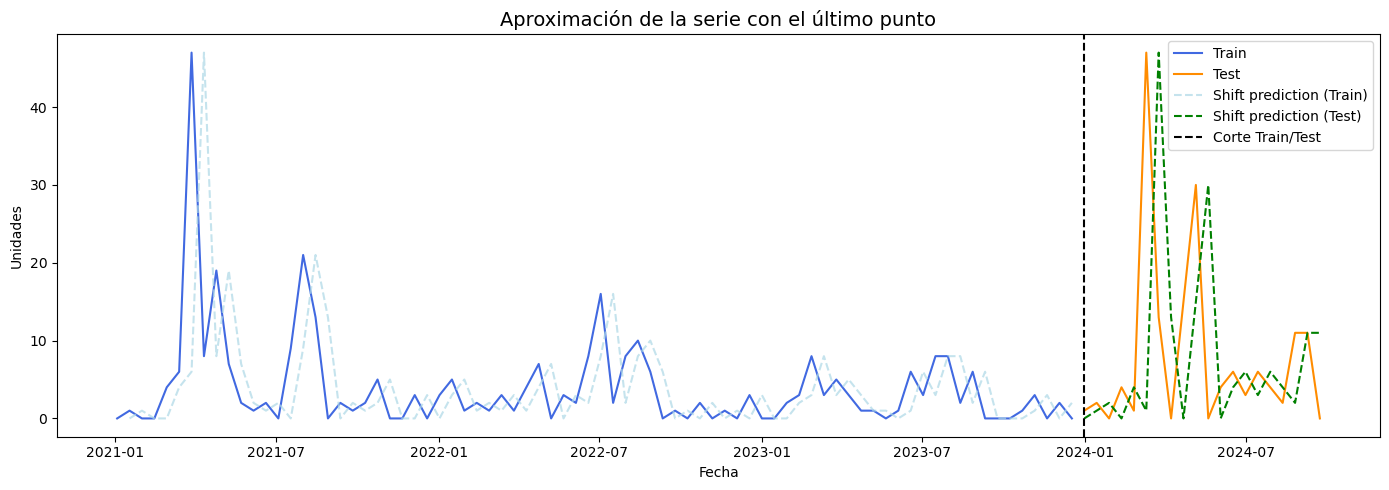

Rendimiento del modelo shift en datos de prueba:
RMSE: 16.33
MAE: 10.47
R² Score: -0.9860


In [8]:
# Crear la serie con predicciones usando shift(1)
y_shift_pred = df['Unidades_y'].shift(1)

# Visualizar todo junto
plt.figure(figsize=(14, 5))
plt.plot(df.index[:train_size], y_train, label='Train', color='royalblue')
plt.plot(df.index[train_size:], y_test, label='Test', color='darkorange')

# Añadir la predicción con shift (separando visual para train y test)
plt.plot(df.index[1:train_size], y_shift_pred[1:train_size], '--', color='lightblue', alpha=0.7, label='Shift prediction (Train)')
plt.plot(df.index[train_size:], y_shift_pred[train_size:], '--', color='green', label='Shift prediction (Test)')

plt.axvline(df.index[train_size], color='black', linestyle='--', label='Corte Train/Test')
plt.title("Aproximación de la serie con el último punto", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluar el rendimiento del modelo shift en los datos de prueba
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Omitir el primer valor de test que sería NaN en la predicción
y_test_eval = y_test[1:]
y_pred_eval = y_shift_pred[train_size+1:]

rmse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
mae = mean_absolute_error(y_test_eval, y_pred_eval)
r2 = r2_score(y_test_eval, y_pred_eval)

print(f"Rendimiento del modelo shift en datos de prueba:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")